**SARIMA BASELINE MODEL**

*This notebook was created and ran using Google Colab.




In [95]:
#Installing some extra packages.
#The session crashes after running this block, but it works properly afterwards.
!pip install -q condacolab
import condacolab
condacolab.install()
!conda install -c conda-forge pmdarima -y

✨🍰✨ Everything looks OK!
Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



# All requested packages already installed.



In [96]:
#Allows us to read our file on google drive.
from google.colab import drive
drive.mount('/content/drive')

#Import basic packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

#Import models needed for ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from sklearn.metrics import mean_squared_error as mse

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
#Reading the data and and reorganizing it so it is easier to read and use.
df = pd.read_csv('/content/drive/My Drive/uk_data_clean.csv')
pivoted = df.pivot(index='datetime', columns='id', values='target')


#Transform the index into Datetime format
def dtarg(x):
  return(pd.to_datetime(x,format='%Y-%m-%d %H:%M:%S'))
pivoted.index = pivoted.index.map(dtarg)


#Split our data into training and testing sets.
#We will reserve the testing set exclusively for testing models.
np.random.seed(216)
testcols = np.random.choice(pivoted.columns, size=int((len(pivoted.columns)*.2)//1), replace=False, p=None)
traincols = [x for x in pivoted.columns if x not in testcols]
energy = pivoted[traincols]
energy_testing_set = pivoted[testcols]

energy.info()
energy_testing_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18960 entries, 2012-11-01 00:00:00 to 2013-11-30 23:30:00
Columns: 736 entries, uk_MAC000010 to uk_MAC005549
dtypes: float64(736)
memory usage: 106.6 MB
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18960 entries, 2012-11-01 00:00:00 to 2013-11-30 23:30:00
Columns: 183 entries, uk_MAC003375 to uk_MAC000769
dtypes: float64(183)
memory usage: 26.6 MB


<Axes: title={'center': 'Household Monthly Average Energy Consumption'}, xlabel='Month', ylabel='Average Energy Consumption (kWh)'>

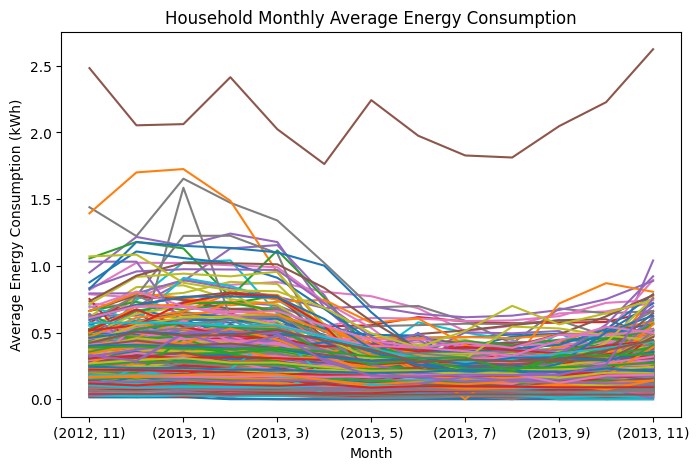

In [98]:
#The data includes 18960 timestamps for a total of 736 + 183 households.
#The following graph shows their monthly average energy consumption.
#We can see a yearly seasonal trend.

energy.groupby([energy.index.year,energy.index.month]).mean().plot(figsize = (8,5),
                                                 legend=False,
                                                 title = 'Household Monthly Average Energy Consumption',
                                                 xlabel = 'Month',
                                                 ylabel = 'Average Energy Consumption (kWh)')



In [99]:
#The data also shows daily and weekly seasonal trends.
#Standard SARIMA models may only handle one type of seasonality.
#SARIMA models using the bihourly data we have are extremely slow.
#We decide to work instead with daily average energy consumption.
#This reduces the amount of data the models with process, and removes the daily seasonality.

daily = energy.groupby(energy.index.date).mean()


#We split our data into a training and a testing time periods.
total_days = daily.shape[0]

split2 = int(0.85 * total_days)

daily_train = daily.iloc[:split2]
daily_test = daily.iloc[split2:]


#It will also be convenient later to have the weekly averages.
weekly_train = daily_train.groupby(np.arange(len(daily_train)) // 7).mean()



ACF and PACF plots for House  284 which has ID uk_MAC002422


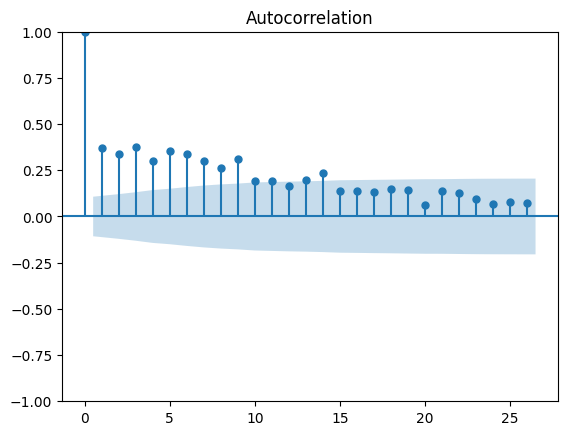

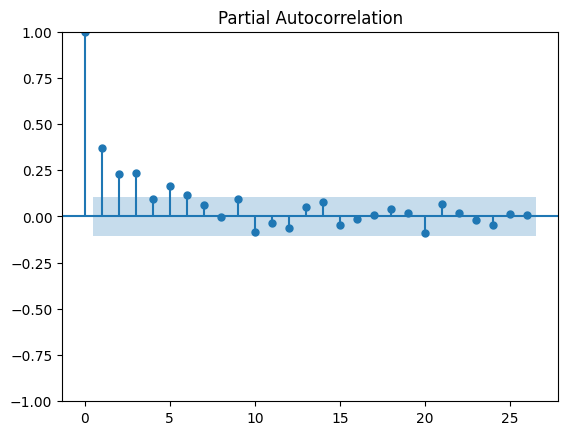

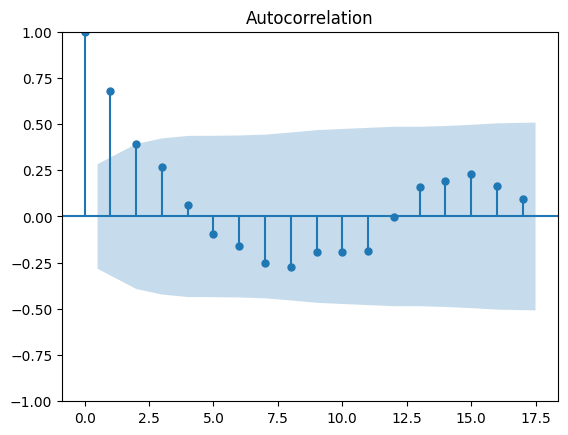

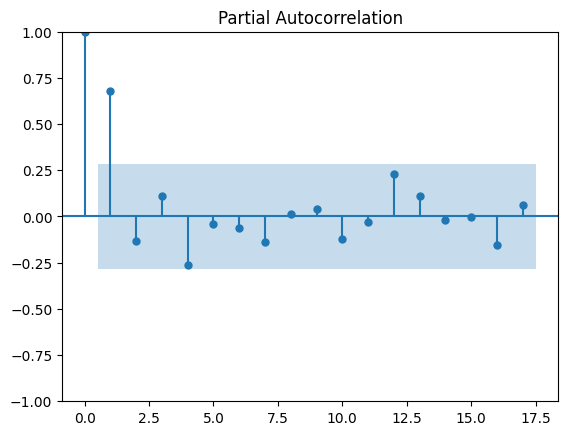

ACF and PACF plots for House  2 which has ID uk_MAC000019


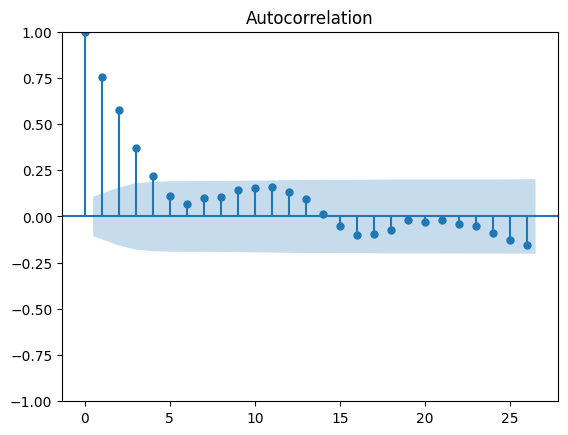

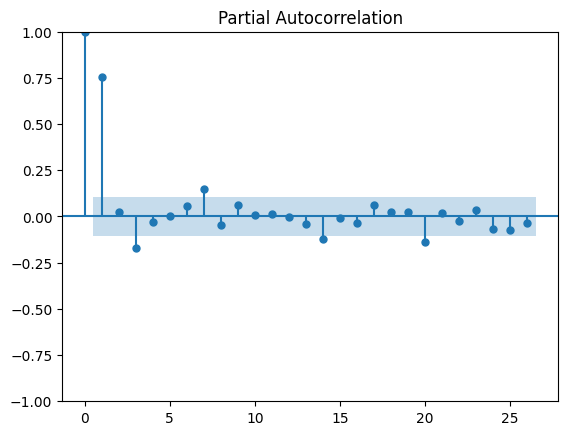

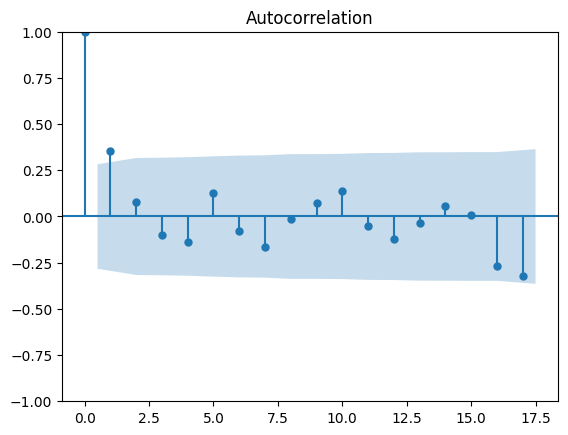

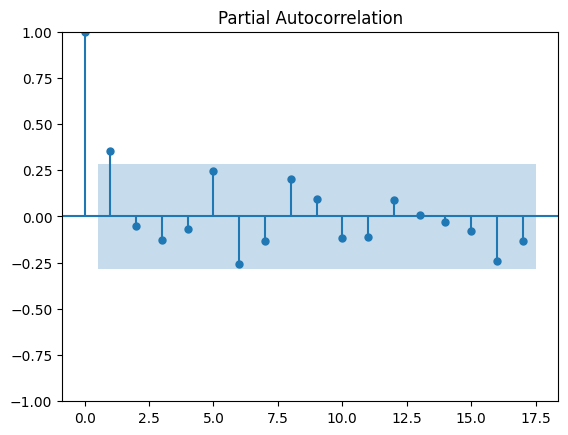

ACF and PACF plots for House  632 which has ID uk_MAC005018


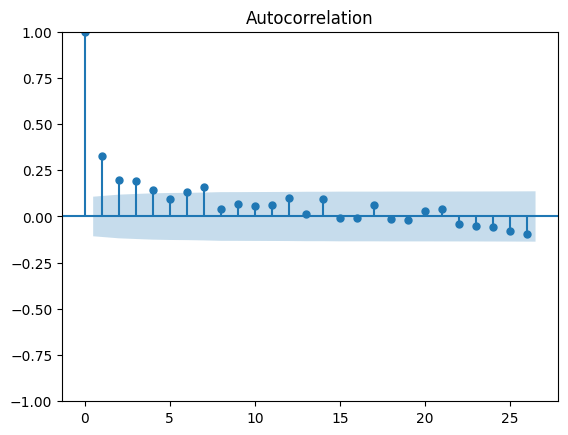

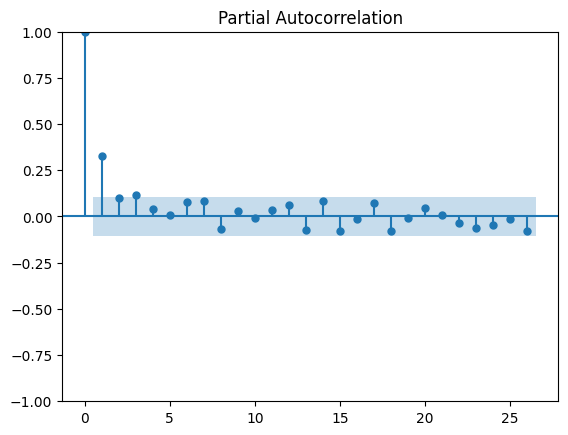

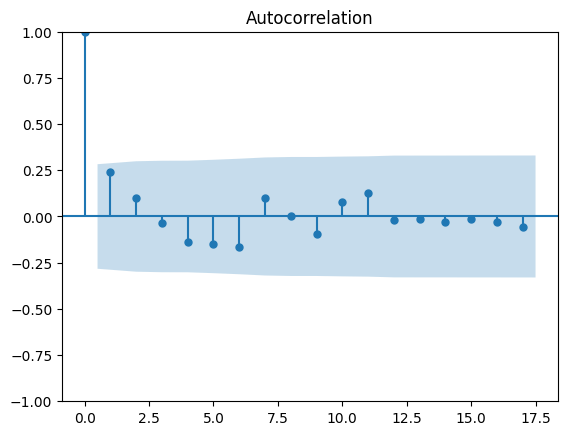

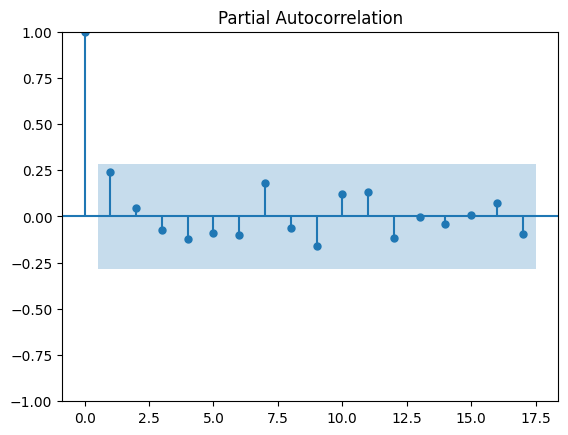

ACF and PACF plots for House  96 which has ID uk_MAC000888


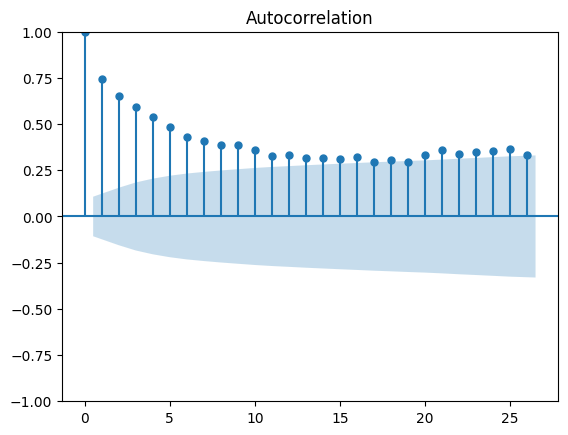

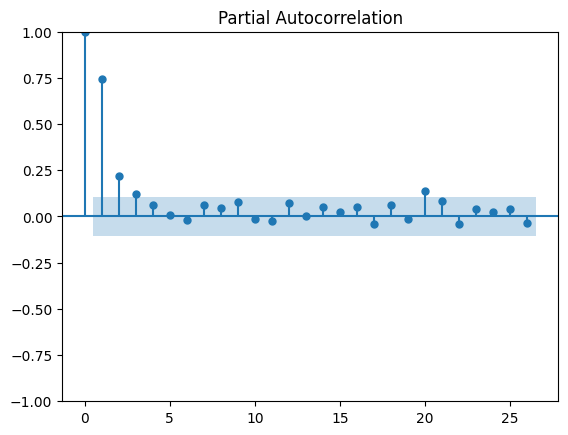

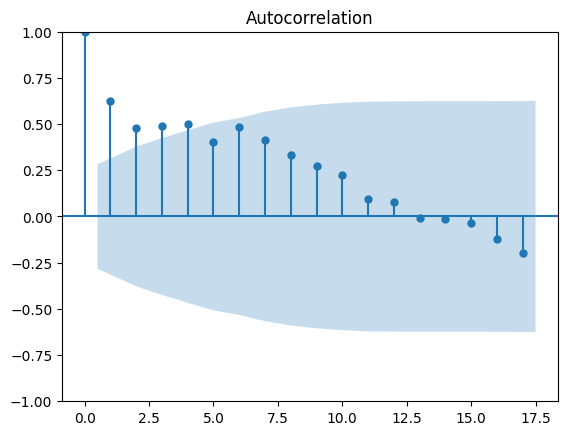

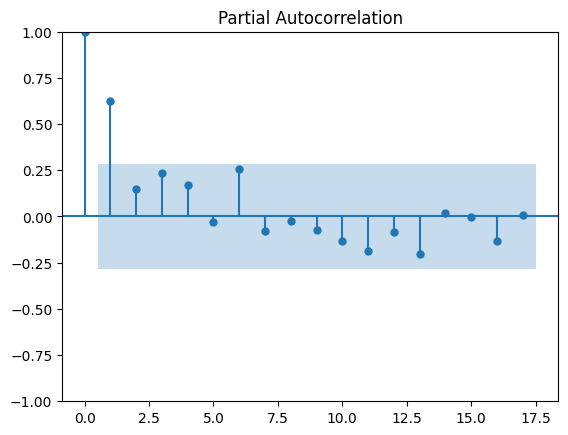

ACF and PACF plots for House  85 which has ID uk_MAC000749


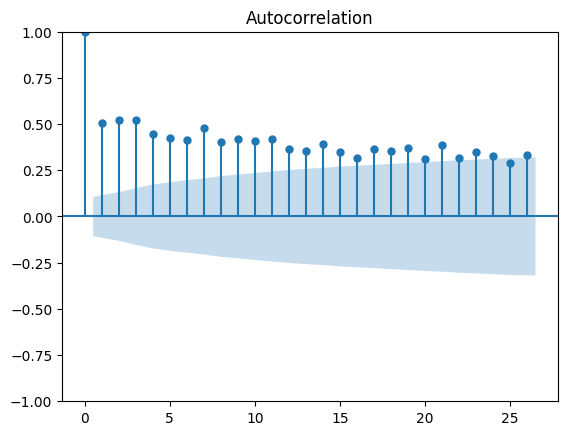

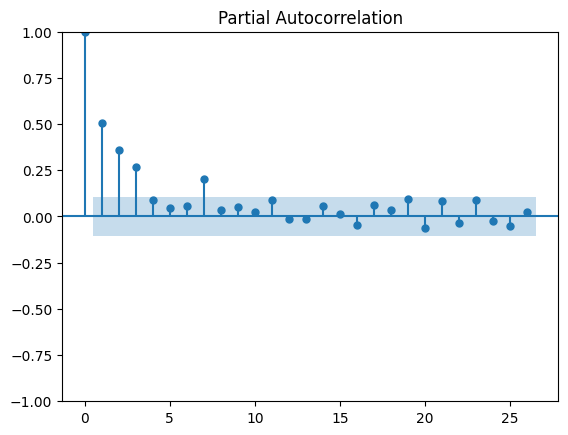

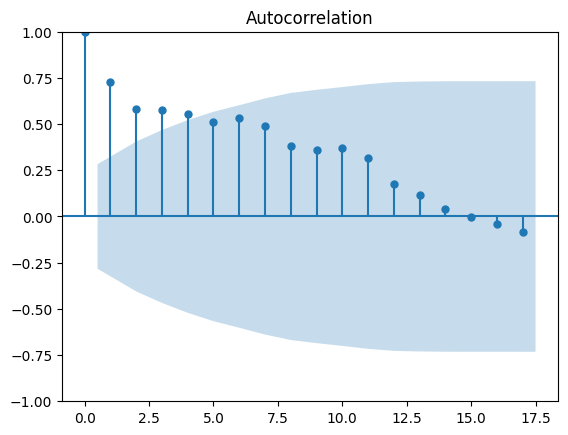

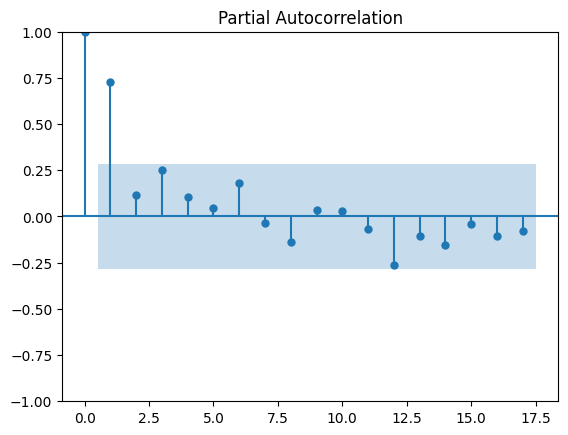

In [100]:
#We will use SARIMA to model a weekly seasonality.
#We plot the acf and pacf for a few random households.
#We use both the daily averages, and weekly averages.

houses = np.random.randint(1, len(energy.columns) - 2, 5)
for i in houses:
  print('ACF and PACF plots for House ', i, 'which has ID', daily_train.columns[i])
  plot_acf(daily_train[daily_train.columns[i]])
  plot_pacf(daily_train[daily_train.columns[i]])
  plot_acf(weekly_train[weekly_train.columns[i]])
  plot_pacf(weekly_train[weekly_train.columns[i]])
  plt.show()

In [101]:
#We wish to set a SARIMA model with order (p,d,q) and seasonal order (P,D,Q,s).
#Multiple parameters were tried manually or via auto_arima.
#Here are the parameters we chose since they gave good results, with a short explanation of why they work.
#From the different ACF and PACF plots we can get some information.
#We usually see a weekly seasonal trend, so we set s=7.
#From looking at the multiple daily pacf plots, we set p=3.
#From the weekly pacf plots, we set P=2.
#From the monthly average graph earlier, approximately showing a parabola, we set D=2.
#From the ACF plots, we choose q=1 and Q=1.
#Since it seemed to work better, we also choose d=2.


#For every household, we create a SARIMA model of order (3,2,1) and seasonal order (2,2,1,7).
#We make predictions using this models and compute the average mse over all households.

daily_mse = []

for i in daily_train.columns:
  daily_arima_i = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train[i])
  daily_mse.append(mse(daily_test[i], daily_arima_i.predict(len(daily_test[i]))))








Se truncaron las últimas líneas 5000 del resultado de transmisión.
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information w

In [102]:
print('Using SARIMA, the average MSE over all training households is ', np.mean(daily_mse))

Using SARIMA, the average MSE over all training households is  0.06763433886478679


In [103]:
#We manually calibrated the parameters of the SARIMA model, in order to minimize the previous MSE.
#Training an individual model, even with fixed hyperparameters, for each household is expensive.
#To conclude with this model, we want the MSE over the testing households.


daily_testing_set = energy_testing_set.groupby(energy_testing_set.index.date).mean()

daily_train_testing_set = daily_testing_set.iloc[:split2]
daily_test_testing_set = daily_testing_set.iloc[split2:]


daily_mse_testing_set = []

for i in daily_train_testing_set.columns:
  daily_arima_i = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train_testing_set[i])
  daily_mse_testing_set.append(mse(daily_test_testing_set[i], daily_arima_i.predict(len(daily_test_testing_set[i]))))


/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
 

In [104]:
print('Using SARIMA, the average MSE over all testing households is ', np.mean(daily_mse_testing_set))

Using SARIMA, the average MSE over all testing households is  0.06277964874603378


In [105]:
#For comparison, we also include a Naive model.
#The model averages the household consumption data from the previous 14 days.

fourteen_days_mean = daily_train[-14:].mean()
fourteen_days_mean_testing_set = daily_train_testing_set[-14:].mean()

daily_mse_naive = []
daily_mse_naive_testing_set = []

for i in daily_train.columns:
  daily_mse_naive.append(mse(daily_test[i], [fourteen_days_mean[i] for j in range(len(daily_test[i]))]))

print('The average MSE over all training households is ', np.mean(daily_mse_naive))

for i in daily_train_testing_set.columns:
  daily_mse_naive_testing_set.append(mse(daily_test_testing_set[i], [fourteen_days_mean_testing_set[i] for j in range(len(daily_test_testing_set[i]))]))

print('The average MSE over all testing households is ', np.mean(daily_mse_naive_testing_set))



The average MSE over all training households is  0.011224555092563851
The average MSE over all testing households is  0.01234085335986967


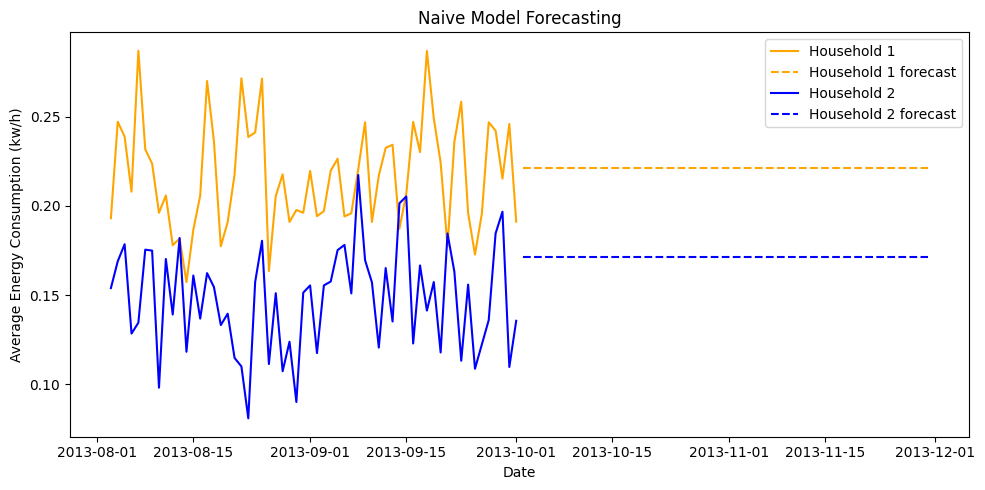

In [106]:
# 1. Create a simple time series
np.random.seed(42)
dates = daily.index
data1 = daily_test_testing_set[daily_test_testing_set.columns[0]]
data1 = data1 * 0 + daily_test_testing_set[daily_test_testing_set.columns[0]][-14:].mean()
data1_train = daily_train_testing_set[daily_train_testing_set.columns[0]][-60:]
data2 = daily_test_testing_set[daily_test_testing_set.columns[1]]
data2 = data2 * 0 + daily_test_testing_set[daily_test_testing_set.columns[1]][-14:].mean()
data2_train = daily_train_testing_set[daily_train_testing_set.columns[1]][-60:]

# 3. Forecast next 10 days

# 4. Plot original data and forecast
plt.figure(figsize=(10,5))
plt.plot(data1_train, label = 'Household 1', color = 'orange')
plt.plot(data1, label='Household 1 forecast', color = 'orange', linestyle = '--')
plt.plot(data2_train, label = 'Household 2', color = 'blue')
plt.plot(data2, label='Household 2 forecast', color = 'blue', linestyle = '--')

#plt.plot(a, forecast, label='Forecast', linestyle='--', marker='o')
plt.title('Naive Model Forecasting')
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption (kw/h)')
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
 daily_arima_0 = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train_testing_set[daily_train_testing_set.columns[0]])
 daily_arima_1 = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(daily_train_testing_set[daily_train_testing_set.columns[1]])



/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
 

/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


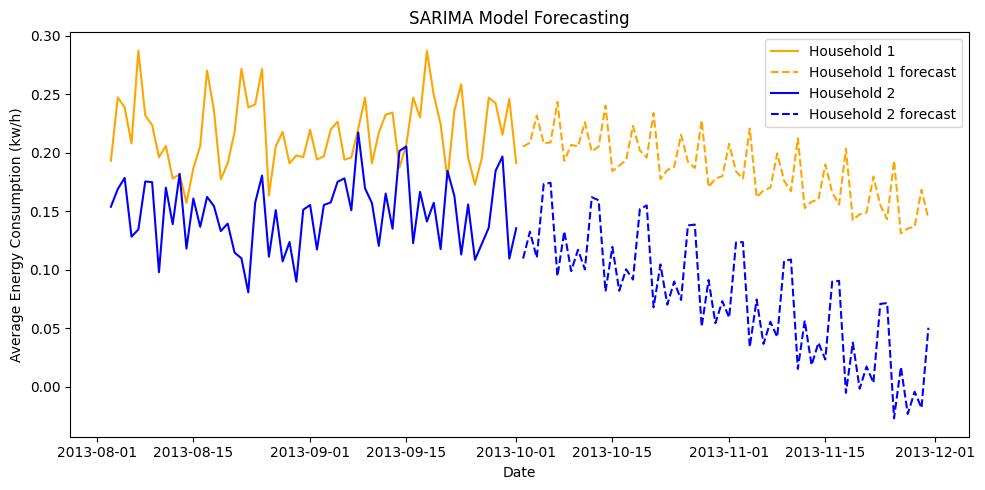

In [108]:
# 1. Create a simple time series
np.random.seed(42)
dates = daily.index
data1 = daily_test_testing_set[daily_test_testing_set.columns[0]]
data1 = data1 * 0 + daily_arima_0.predict(len(data1))
data1_train = daily_train_testing_set[daily_train_testing_set.columns[0]][-60:]
data2 = daily_test_testing_set[daily_test_testing_set.columns[1]]
data2 = data2 * 0  + daily_arima_1.predict(len(data2))
data2_train = daily_train_testing_set[daily_train_testing_set.columns[1]][-60:]

# 3. Forecast next 10 days

# 4. Plot original data and forecast
plt.figure(figsize=(10,5))
plt.plot(data1_train, label = 'Household 1', color = 'orange')
plt.plot(data1, label='Household 1 forecast', color = 'orange', linestyle = '--')
plt.plot(data2_train, label = 'Household 2', color = 'blue')
plt.plot(data2, label='Household 2 forecast', color = 'blue', linestyle = '--')

#plt.plot(a, forecast, label='Forecast', linestyle='--', marker='o')
plt.title('SARIMA Model Forecasting')
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption (kw/h)')
plt.legend()
plt.tight_layout()
plt.show()

In [109]:
#Let's change up the model instead, to compare it better to our original LSTM model.
#Instead of forcasting a month, we will forcast a day at a time, using all existing past data.
#We will only do this over a subset of the testing set, as this should be extremely expensive.

subset_cols = np.random.choice(energy_testing_set.columns, size = 4, replace = False, p=None)
subset = energy_testing_set[subset_cols]
subset.info()


#Let's average things by day again.
subset_daily = subset.groupby(subset.index.date).mean()


#Let's split our data
subset_daily_train = subset_daily.iloc[:split2]
subset_daily_test = subset_daily.iloc[split2:]


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 18960 entries, 2012-11-01 00:00:00 to 2013-11-30 23:30:00
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uk_MAC000281  18960 non-null  float64
 1   uk_MAC003512  18960 non-null  float64
 2   uk_MAC004903  18960 non-null  float64
 3   uk_MAC004085  18960 non-null  float64
dtypes: float64(4)
memory usage: 740.6 KB


In [110]:
#We can now train our models. We need to train, for each household, len(subset_daily_test)=60 models.

forcasted_values = subset_daily_test * 0


for house in subset_daily.columns:
  for i in range(len(subset_daily_test)):
    data = pd.concat([subset_daily_train, subset_daily_test[:i]])[house]
    arima = pm.ARIMA(order=(3, 2, 1), seasonal_order=(2,2,1,7) , with_intercept = False).fit(data)
    forcasted_values[house][i] = arima.predict(1)[0]

forcasted_values


Se truncaron las últimas líneas 5000 del resultado de transmisión.
  forcasted_values[house][i] = arima.predict(1)[0]
/usr/local/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.11/site-packages/sklearn/utils/depreca

id,uk_MAC000281,uk_MAC003512,uk_MAC004903,uk_MAC004085
2013-10-02,0.158042,0.139411,0.245313,0.280447
2013-10-03,0.180093,0.209303,0.287194,0.241818
2013-10-04,0.170262,0.123077,0.160886,0.260007
2013-10-05,0.191462,0.179886,0.085703,0.295266
2013-10-06,0.228369,0.241734,0.213271,0.363606
2013-10-07,0.158209,0.135335,0.112159,0.396626
2013-10-08,0.184961,0.119435,0.201883,0.333594
2013-10-09,0.172071,0.155565,0.291974,0.288950
2013-10-10,0.182557,0.072336,0.122458,0.280335
2013-10-11,0.163858,0.216900,0.187068,0.305096


In [111]:
#Let's see what the mse is now.
#Doing this for just three houses took an enormous amount of time.
print('The MSE using ARIMA and these houses is', mse(forcasted_values, subset_daily_test))

The MSE using ARIMA and these houses is 0.003532086103632123


In [112]:
#We can also compare this with a naive model that only takes the average energy consumption of the previous day
naive_forcasted_values = pd.concat([subset_daily_train[-1:], subset_daily_test[:-1]])
print('The MSE using the naive model and these houses is', mse(naive_forcasted_values, subset_daily_test))


The MSE using the naive model and these houses is 0.004237162121776987
